# Sprint 3 : Optimisation du modèle retenu
### Projet : Prédiction du risque de diabète - BRFSS 2015
---
**Formation** : FISE A4 Data & IA - CESI Bordeaux  
**Dataset** : `diabetes_012_health_indicators_BRFSS2015.csv`  
**Livrable** : Sprint 3 : Optimisation, enrichissement et évaluation finale du modèle


## Sommaire

1. Contexte
2. Objectifs
3. Contraintes
4. Imports et configuration
5. Chargement des datasets
6. Choix du framework d'optimisation
7. Gestion du déséquilibre des classes
8. Espace de recherche et fonctions utilitaires
9. Optimisation du Modèle B
   - 9.1 Recherche automatique des hyperparamètres
   - 9.2 Entraînement du modèle B optimisé
   - 9.3 Évaluation sur la validation
10. Optimisation du Modèle C
   - 10.1 Recherche automatique des hyperparamètres
   - 10.2 Entraînement du modèle C optimisé
   - 10.3 Évaluation sur la validation
11. Comparaison des modèles optimisés
12. Analyse du seuil de décision
13. Évaluation finale sur le jeu de test
14. IA explicable (SHAP et LIME)
15. Empreinte carbone
16. Conclusion
17. Bibliographie

## 1. Contexte

&nbsp;&nbsp;&nbsp;&nbsp;Aux États-Unis, le diabète est l'une des maladies chroniques les plus répandues. En 2018, les CDC (les Centres pour le contrôle et la prévention des maladies) estimaient à 34,2 millions le nombre d'Américains diabétiques, et à 88 millions ceux en état de prédiabète, dont une grande majorité ignorait leur situation.

Cette maladie cause un dérèglement du sucre sanguin, ce qui, sur le long terme, peut engendrer des complications graves : maladies cardiovasculaires, insuffisance rénale, amputations, perte de la vue. Son coût économique est estimé à près de 300 milliards de dollars par an.

Le dataset utilisé provient du *Behavioral Risk Factor Surveillance System (BRFSS)*, une enquête téléphonique annuelle menée par les CDC auprès de plus de 400 000 Américains. Notre version (2015) contient 253 680 réponses et 22 variables relatives aux comportements de santé, antécédents médicaux et conditions socio-économiques des participants.

&nbsp;&nbsp;&nbsp;&nbsp;Le **livrable 3** constitue la partie "Optimisation et évaluation finale" du projet.  
Dans le livrable 2, nous avons construit et comparé trois architectures de réseaux de neurones de complexité croissante. Le **Modèle B** (2 couches cachées, architecture de 16 neurones puis 8 neurones) a été retenu comme point de départ pour ce livrable. Non pas parce qu'il obtient les meilleurs résultats bruts, mais parce qu'il représente le meilleur compromis entre capacité d'apprentissage et stabilité, et parce que ses résultats limités s'expliquent par des hyperparamètres génériques qui ne lui sont pas adaptés.  
C'est exactement le cas d'usage pour lequel la recherche automatique d'hyperparamètres est faite.  

L'objectif de ce livrable est de l'enrichir et de l'optimiser pour améliorer ses performances, en particulier sur le recall, qui est notre métrique médicale prioritaire.

L'échéance de ce livrable est fixée au 2 juin 2026 à 8h.

## 2. Objectifs

L'objectif de ce livrable est d'améliorer les performances du Modèle B issu du livrable 2.

D'abord, il s'agit d'explorer plusieurs axes d'optimisation : recherche automatique des hyperparamètres, meilleure gestion du déséquilibre des classes, et analyse du seuil de décision. L'idée est de comprendre ce qui freine le modèle et d'agir dessus de manière méthodique.

Ensuite, il s'agit d'évaluer le modèle enrichi sur le jeu de test et de le comparer au Modèle B du livrable 2 pour mesurer concrètement les gains obtenus.

À la fin de ce livrable, on devra être capables de dire si les optimisations apportées améliorent significativement les performances médicales du modèle, et dans quelle mesure il se rapproche d'un niveau acceptable pour une aide à la décision clinique.

## 3. Contraintes

Les contraintes de ce livrable sont les mêmes que celles du livrable 2, auxquelles s'ajoutent de nouvelles exigences liées à la finalisation du projet :

- Elles sont **médicales**. Si le modèle ne détecte pas un diabète chez un patient (un faux négatif), c'est bien plus grave que de signaler un diabète chez un patient qui n'en a pas. Une consultation supplémentaire "pour rien" est moins grave qu'un patient qui ne sait pas qu'il est diabétique. Maximiser le recall reste donc notre priorité absolue.

- Elles sont **éthiques**. Le modèle est amené à être utilisé par des médecins. Des vies humaines sont en jeu et ce dernier a un impact direct sur l'avenir des patients.

- Le modèle doit trouver le juste milieu entre performance et explicabilité. Puisque des médecins sont amenés à l'utiliser, ils doivent pouvoir en interpréter les résultats. Si le modèle est trop complexe, il n'est pas ou peu explicable et donc pas utilisable dans la pratique.

- Le modèle doit être capable de **généraliser**, c'est-à-dire qu'il doit éviter le **surapprentissage** pour fonctionner correctement sur de nouvelles données qu'il n'a jamais vues.  
Un modèle en surapprentissage mémorise les données d'entraînement au lieu d'en apprendre les patterns généraux, il performe très bien à l'entraînement mais devient inefficace face à de nouvelles données.

- Le jeu de données présente un **déséquilibre des classes** important (86% de non-diabétiques contre 14% de diabétiques). Ce déséquilibre a été partiellement traité dans le livrable 1 via SMOTE sur le jeu d'entraînement, mais les jeux de validation et de test conservent la distribution réelle.  
L'accuracy seule ne suffit donc pas comme métrique d'évaluation.

- Le modèle déployé en production engage la responsabilité du praticien et doit répondre aux exigences de l'**AI Act européen (Annexe III point 5)**, qui impose des standards de fiabilité, de transparence et de contrôle humain pour les systèmes à haut risque comme les outils d'aide au diagnostic.

## 4. Imports et configuration


In [1]:
# Suppression des avertissements non critiques
import warnings
warnings.filterwarnings('ignore')

# Librairies de base
import numpy as np
import pandas as pd
import time
import os
from codecarbon import EmissionsTracker
# Sécurités anti-crash sur Windows (conflit de runtimes natifs entre TF, numba et scikit-image)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=tout, 1=info, 2=warning, 3=error seulement

DATA_PATH = 'data/processed/'

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Recall
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Recherche d'hyperparamètres
import keras_tuner as kt


# Métriques d'évaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# Configuration graphique
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)

# Graine aléatoire pour la reproductibilité des résultats
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print('TensorFlow version :', tf.__version__)
print('Imports OK')

TensorFlow version : 2.21.0
Imports OK


## 5. Chargement des datasets


In [2]:
# Features
X_train = pd.read_csv(os.path.join(DATA_PATH, 'X_train.csv'))
X_val   = pd.read_csv(os.path.join(DATA_PATH, 'X_val.csv'))
X_test  = pd.read_csv(os.path.join(DATA_PATH, 'X_test.csv'))

# Labels
y_train = pd.read_csv(os.path.join(DATA_PATH, 'y_train.csv'))
y_val   = pd.read_csv(os.path.join(DATA_PATH, 'y_val.csv'))
y_test  = pd.read_csv(os.path.join(DATA_PATH, 'y_test.csv'))

# Aperçu des dimensions
print('X_train :', X_train.shape)
print('X_val   :', X_val.shape)
print('X_test  :', X_test.shape)
print('y_train :', y_train.shape)
print('y_val   :', y_val.shape)
print('y_test  :', y_test.shape)

X_train : (305668, 18)
X_val   : (38052, 18)
X_test  : (38052, 18)
y_train : (305668, 1)
y_val   : (38052, 1)
y_test  : (38052, 1)


## 6. Choix du framework d'optimisation

### Pourquoi chercher des hyperparamètres automatiquement ?

Dans le livrable 2, tous les modèles partageaient les mêmes hyperparamètres. C'était un choix délibéré pour que la comparaison soit honnête. Mais ce que le livrable 2 a montré, c'est que le Modèle B ne performe pas mal à cause de son architecture, il performe mal parce que ses hyperparamètres (learning rate, dropout, taille des couches, régularisation L2) ne lui sont pas adaptés.

Chercher manuellement la bonne combinaison serait long, pas rigoureux, et non reproductible. On utilise donc un framework de **recherche automatique d'hyperparamètres** qui va tester de nombreuses combinaisons de manière systématique et retenir celle qui donne les meilleurs résultats sur la validation.

### Comparaison des frameworks

Nous allons analyser deux options : **Keras Tuner** et **Optuna**.

- **Optuna** est un framework de recherche d'hyperparamètres agnostique au framework de deep learning. Il utilise par défaut une optimisation bayésienne via l'algorithme TPE (Tree-structured Parzen Estimator), ce qui le rend efficace pour explorer des espaces de recherche complexes.  
Il est particulièrement adapté quand on veut optimiser des pipelines hétérogènes (par exemple, un prétraitement + un modèle sklearn + un modèle Keras dans la même recherche).  
Sa flexibilité est grande mais elle demande plus de configuration manuelle. Nous devons définir nous-même la fonction objective, les essais, et les règles d'arrêt.

- **Keras Tuner** est le framework d'optimisation d'hyperparamètres pour Keras. Il s'intègre directement avec l'API Keras sans aucune configuration supplémentaire. On définit les hyperparamètres directement dans la fonction de construction du modèle avec `hp.Int`, `hp.Float`, `hp.Choice`, et Keras Tuner s'occupe du reste.  
Il propose plusieurs stratégies de recherche comme RandomSearch, Hyperband, BayesianOptimization et gère automatiquement l'EarlyStopping, la sauvegarde des meilleurs poids et les logs.

### Pourquoi on choisit Keras Tuner

Depuis le livrable 2, on utilise TensorFlow / Keras pour construire, entraîner et évaluer nos réseaux de neurones. Keras Tuner est conçu pour fonctionner directement avec cette librairie, sans configuration supplémentaire, ce qui évite d'introduire une nouvelle dépendance pour rien.

Optuna serait pertinent si on voulait optimiser un pipeline plus complexe ou comparer plusieurs frameworks de deep learning entre eux. Ce n'est pas notre cas. Ici on optimise un seul modèle Keras avec des hyperparamètres bien identifiés.  
L'utiliser ici ajouterait de la complexité sans apporter de bénéfice.

Enfin, Keras Tuner propose **Hyperband**, une stratégie bien adaptée à notre situation. On a beaucoup de combinaisons à tester et un budget de calcul limité. Hyperband résout ce problème en allouant plus de ressources aux combinaisons prometteuses et en arrêtant tôt celles qui ne donnent rien, ce qui le rend bien plus efficace qu'une recherche aléatoire classique.

C'est pour ces raisons qu'on retient **Keras Tuner avec la stratégie Hyperband**.

## 7. Gestion du déséquilibre des classes

### Rappel du déséquilibre

Comme établi dans le livrable 1, le dataset présente un déséquilibre important entre les deux classes. Le jeu d'entraînement contient environ 86% de non-diabétiques et 14% de diabétiques. Sans traitement, le modèle aurait tendance à privilégier la classe majoritaire et à ignorer les diabétiques, ce qui va directement à l'encontre des contraintes médicales du projet.

Dans le livrable 1, ce déséquilibre a été traité sur le jeu d'entraînement via **SMOTE** (Synthetic Minority Oversampling Technique). On rappelle ici son fonctionnement et on le compare à une alternative pour justifier pourquoi on le conserve dans ce livrable.

### SMOTE vs Class Weight

- **SMOTE** génère de nouveaux exemples synthétiques de la classe minoritaire en interpolant entre des exemples existants. Concrètement, pour chaque exemple diabétique, SMOTE sélectionne ses voisins les plus proches dans l'espace des features et crée de nouveaux points entre eux.  
Le jeu d'entraînement est ainsi rééquilibré sans dupliquer les mêmes exemples, ce qui force le modèle à apprendre des patterns plus variés sur la classe minoritaire. 

- **Class Weight** est une alternative plus simple qui ne modifie pas les données. On attribue un poids plus élevé à la classe minoritaire dans la fonction de loss. Une erreur sur un diabétique coûte proportionnellement plus cher au modèle qu'une erreur sur un non-diabétique.  
Le modèle est ainsi incité à mieux classer les diabétiques sans qu'on touche au dataset.

Les deux approches ont leurs avantages :  

Class Weight est plus rapide à mettre en place et ne crée pas de données synthétiques, ce qui peut être un avantage dans des contextes où la génération de données médicales est un soucis éthique (Cela depend du contexte, ce qui n'est pas notre cas, les données etant deja anonymisé).   
En revanche, SMOTE enrichit réellement le jeu d'entraînement avec de la diversité sur la classe minoritaire, ce qui aide le modèle à mieux généraliser sur des cas limites qu'il n'aurait pas vus autrement.

Dans notre cas, on conserve le SMOTE car il a déjà été appliqué dans le livrable 1. Changer de méthode maintenant fausserait la comparaison avec le Modèle B du livrable 2.

Distribution des classes (train après SMOTE) :
  Classe 0 : 152834 (50.0%)
  Classe 1 : 152834 (50.0%)


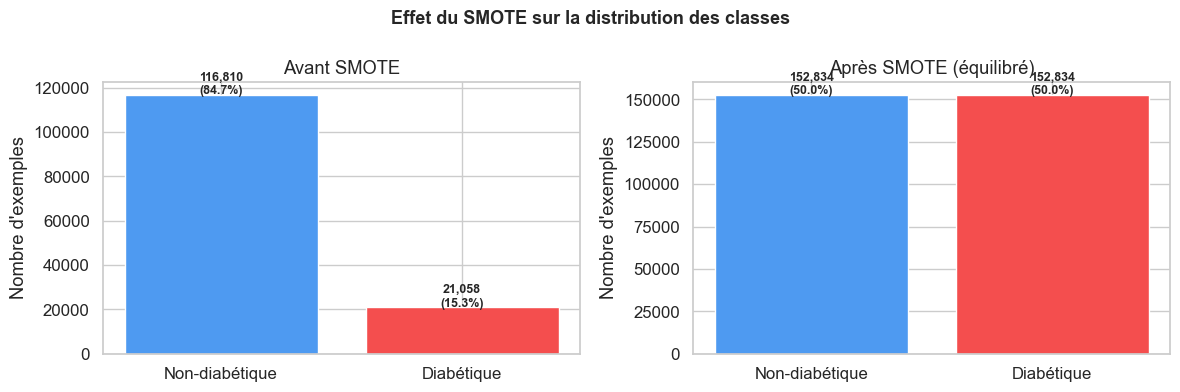

In [3]:
# Données avant SMOTE
counts_before = [116810, 21058]

# Données après SMOTE
unique, counts = np.unique(y_train, return_counts = True)
counts_after   = list(counts)

print('Distribution des classes (train après SMOTE) :')
for cls, cnt in zip(unique, counts):
    pct = cnt / len(y_train) * 100
    print(f'  Classe {int(cls)} : {cnt} ({pct:.1f}%)')

# Graphique
colors = ['#4e9af1', '#f44e4e']
labels = ['Non-diabétique', 'Diabétique']

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# Avant SMOTE
bars = axes[0].bar(labels, counts_before, color = colors)
axes[0].set_title('Avant SMOTE')
axes[0].set_ylabel("Nombre d'exemples")
total = sum(counts_before)
for bar, val in zip(bars, counts_before):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f'{val:,}\n({val / total * 100:.1f}%)', ha = 'center', fontsize = 9, fontweight = 'bold')

# Après SMOTE
bars = axes[1].bar(labels, counts_after, color = colors)
axes[1].set_title('Après SMOTE (équilibré)')
axes[1].set_ylabel("Nombre d'exemples")
total = sum(counts_after)
for bar, val in zip(bars, counts_after):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f'{val:,}\n({val / total * 100:.1f}%)', ha = 'center', fontsize = 9, fontweight = 'bold')

plt.suptitle('Effet du SMOTE sur la distribution des classes', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.show()

## 8. Espace de recherche et fonctions utilitaires

Avant de lancer la recherche, on doit définir deux choses : quels hyperparamètres on laisse Keras Tuner explorer, et quelques fonctions qu'on va réutiliser tout le long du livrable pour évaluer les modèles. Ça évite de réécrire le même code à chaque fois.

### Ce qu'on garde fixe et ce qu'on fait varier

On ne touche pas à la profondeur des modèles : le Modèle B garde ses deux couches cachées et le Modèle C ses trois couches, exactement comme au livrable 2. Ce qui change, c'est qu'au livrable 2 tout le reste était figé à la main, alors qu'ici on laisse le framework chercher la meilleure combinaison pour :

- le **nombre de neurones** de chaque couche cachée,
- le **taux de dropout**,
- la **régularisation L2**,
- le **learning rate**.

On ajoute aussi deux paramètres supplémentaires qu'on n'avait pas du tout testés dans le livrable 2 et qui servent à enrichir l'architecture :

- la **fonction d'activation** (`relu`, `tanh`, `elu`, `selu`) : jusqu'ici on utilisait toujours `relu` par défaut, mais rien ne dit que c'est la meilleure pour nos données.
- la **BatchNormalization** après chaque couche Dense : c'est une couche qui normalise les sorties entre les couches. Ça stabilise l'entraînement et ça aide souvent à réduire le surapprentissage, qui était justement notre gros problème dans le livrable 2. On la rend optionnelle (le tuner choisit de l'activer ou non).

Pour chaque paramètre numérique on définit une plage qui donne **environ une dizaine de valeurs possibles**, pour que la recherche ait de quoi explorer sans exploser le temps de calcul.

### Sur quoi on optimise ?

On dit à Keras Tuner de maximiser le **ROC-AUC sur la validation** (`val_auc`). On ne l'optimise pas directement sur le recall, et c'est volontaire.  
En effet, le recall dépend du seuil de décision, et le seuil on le réglera nous-mêmes juste après (section 12). Le ROC-AUC, lui, mesure la capacité du modèle à séparer les deux classes indépendamment du seuil. Donc on cherche d'abord le modèle qui sépare le mieux, et ensuite on règle le seuil pour attraper un maximum de diabétiques.

### Callbacks

On garde l'**EarlyStopping** pour couper l'entraînement quand la validation ne progresse plus (anti-surapprentissage), et on ajoute **ReduceLROnPlateau** qui réduit automatiquement le learning rate quand la loss stagne. Ça aide le modèle à affiner sa descente en fin d'entraînement au lieu de tourner en rond.

In [4]:
# Nombre de features en entrée
input_dim = X_train.shape[1]
print(f'Nombre de features en entrée : {input_dim}')

# y en tableau 1D (plus pratique pour les métriques sklearn)
y_train_arr = np.array(y_train).ravel()
y_val_arr   = np.array(y_val).ravel()
y_test_arr  = np.array(y_test).ravel()

Nombre de features en entrée : 18


In [5]:
# Fonction d'évaluation : calcule et affiche toutes les métriques
def evaluer(model, X, y, seuil = 0.5, nom = ''):
    y_prob = model.predict(X, verbose = 0).ravel()
    y_pred = (y_prob >= seuil).astype(int)

    acc  = accuracy_score(y,  y_pred)
    prec = precision_score(y, y_pred, zero_division = 0)
    rec  = recall_score(y,    y_pred, zero_division = 0)
    f1   = f1_score(y,        y_pred, zero_division = 0)
    auc  = roc_auc_score(y,   y_prob)

    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f'Résultats {nom} (seuil = {seuil})')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  TN = {tn}  FP = {fp}')
    print(f'  FN = {fn}  TP = {tp}')
    print(f'  {fn} diabétiques non détectés (faux négatifs)')

    return {'nom': nom, 'seuil': seuil, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'auc': auc,
            'fn': int(fn), 'fp': int(fp), 'y_prob': y_prob}


# Fonction d'analyse du seuil
def analyse_seuil(y, y_prob, nom_modele, seuils = None):
    if seuils is None:
        seuils = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
    resultats = []
    for s in seuils:
        y_pred = (y_prob >= s).astype(int)
        rec  = recall_score(y,    y_pred, zero_division = 0)
        prec = precision_score(y, y_pred, zero_division = 0)
        f1   = f1_score(y,        y_pred, zero_division = 0)
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
        resultats.append({'Seuil': s, 'Recall': round(rec, 4),
                          'Precision': round(prec, 4), 'F1-score': round(f1, 4),
                          'FN': fn, 'FP': fp})
    df = pd.DataFrame(resultats).set_index('Seuil')
    print(f'\nAnalyse du seuil : {nom_modele}')
    print(df.to_string())
    return df


# Choix du seuil : on garde le plus grand seuil qui respecte encore la cible de recall
def choisir_seuil(y, y_prob, recall_cible = 0.85):
    seuil_retenu = 0.5
    for s in np.round(np.arange(0.05, 0.96, 0.05), 2):
        rec = recall_score(y, (y_prob >= s).astype(int), zero_division = 0)
        if rec >= recall_cible:
            seuil_retenu = s
    return seuil_retenu


# Fonction pour tracer les courbes d'apprentissage
def tracer_courbes(history, nom = ''):
    fig, axes = plt.subplots(1, 2, figsize = (14, 4))
    axes[0].plot(history.history['loss'],     label = 'Train')
    axes[0].plot(history.history['val_loss'], label = 'Validation')
    axes[0].set_title('Loss');     axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(history.history['auc'],     label = 'Train')
    axes[1].plot(history.history['val_auc'], label = 'Validation')
    axes[1].set_title('ROC-AUC');  axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.suptitle(f'Courbes d\'apprentissage : {nom}', fontsize = 13, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

print('Fonctions utilitaires définies.')

Fonctions utilitaires définies.


## 9. Optimisation du Modèle B

On part du Modèle B du livrable 2 (deux couches cachées) et on le confie à Keras Tuner. Le but c'est de trouver la combinaison d'hyperparamètres qui lui correspond vraiment, au lieu des paramètres choisit au hasard qu'on lui avait imposés.

### 9.1 Recherche automatique des hyperparamètres

On définit d'abord la fonction qui construit le modèle. Le nombre de couches reste fixe. Au lieu de mettre des valeurs fixes pour le reste, on utilise `hp.Int`, `hp.Float`, `hp.Choice` et `hp.Boolean`, c'est comme ça qu'on dit à Keras Tuner quelles valeurs il a le droit de tester pour chaque hyperparamètre.

In [6]:
# Fonction de construction du Modèle B avec hyperparamètres variables

def construire_modele_B(hp):
    # Les deux nouveaux paramètres
    activation = hp.Choice('activation', ['relu', 'tanh', 'elu', 'selu'])
    batchnorm  = hp.Boolean('batchnorm')

    # Les hyperparamètres
    units_1 = hp.Int('units_1', min_value = 8, max_value = 80, step = 8)   # neurones couche 1
    units_2 = hp.Int('units_2', min_value = 4, max_value = 40, step = 4)   # neurones couche 2
    dropout = hp.Float('dropout', min_value = 0.1, max_value = 0.5, step = 0.05)
    l2_reg  = hp.Choice('l2_reg', [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3])
    lr      = hp.Choice('learning_rate', [1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3])

    model = Sequential(name = 'model_B_opt')
    model.add(Input(shape = (input_dim,)))

    # Couche cachée 1 : Dense puis (BatchNorm) puis Activation puis Dropout
    model.add(Dense(units_1, kernel_regularizer = l2(l2_reg)))
    if batchnorm:
        model.add(BatchNormalization())
    model.add(Activation(activation))
    model.add(Dropout(dropout))

    # Couche cachée 2
    model.add(Dense(units_2, kernel_regularizer = l2(l2_reg)))
    if batchnorm:
        model.add(BatchNormalization())
    model.add(Activation(activation))
    model.add(Dropout(dropout))

    # Sortie
    model.add(Dense(1, activation = 'sigmoid'))

    model.compile(
        optimizer = Adam(learning_rate = lr),
        loss = 'binary_crossentropy',
        metrics = ['accuracy', AUC(name = 'auc'), Recall(name = 'recall')]
    )
    return model

print('Fonction de construction du Modèle B définie.')

Fonction de construction du Modèle B définie.


In [7]:
# Recherche Hyperband sur le Modèle B
tuner_B = kt.Hyperband(
    construire_modele_B,
    objective = kt.Objective('val_auc', direction = 'max'),
    max_epochs = 15,
    factor = 3,
    hyperband_iterations = 1,
    directory = 'keras_tuner',
    project_name = 'modele_B',
    overwrite = True,
    seed = RANDOM_STATE
)

# EarlyStopping pendant la recherche pour ne pas perdre de temps sur les mauvaises combinaisons
stop_recherche = EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

# Lancement de la recherche
tuner_B.search(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 15,
    batch_size = 1024,
    callbacks = [stop_recherche],
    verbose = 1
)

# Récupération des meilleurs hyperparamètres
best_hp_B = tuner_B.get_best_hyperparameters(num_trials = 1)[0]

print('\nMeilleurs hyperparamètres trouvés pour le Modèle B :')
for p in ['units_1', 'units_2', 'activation', 'batchnorm', 'dropout', 'l2_reg', 'learning_rate']:
    print(f'  {p:14}: {best_hp_B.get(p)}')

Trial 30 Complete [00h 00m 15s]
val_auc: 0.7956483364105225

Best val_auc So Far: 0.7996951937675476
Total elapsed time: 00h 03m 34s

Meilleurs hyperparamètres trouvés pour le Modèle B :
  units_1       : 40
  units_2       : 4
  activation    : tanh
  batchnorm     : False
  dropout       : 0.1
  l2_reg        : 0.001
  learning_rate : 0.002


### 9.2 Entraînement du modèle B optimisé

On reconstruit le modèle avec les meilleurs hyperparamètres trouvés, et on l'entraîne pour de vrai cette fois (plus d'epochs que pendant la recherche). On ajoute `ReduceLROnPlateau` en plus de l'`EarlyStopping`.

In [8]:
# Construction du modèle avec les meilleurs hyperparamètres
model_B_opt = tuner_B.hypermodel.build(best_hp_B)
model_B_opt.summary()

# Callbacks pour l'entraînement final
callbacks_B = [
    EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_lr = 1e-6)
]

history_B = model_B_opt.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 50,
    batch_size = 1024,
    callbacks = callbacks_B,
    verbose = 1
)

Model: "model_B_opt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 40)                  │             760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 40)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 40)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4)                   │             164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7255 - auc: 0.7979 - loss: 0.5665 - recall: 0.7590 - val_accuracy: 0.7010 - val_auc: 0.7958 - val_loss: 0.5634 - val_recall: 0.7591 - learning_rate: 0.0020
Epoch 2/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7390 - auc: 0.8130 - loss: 0.5354 - recall: 0.7745 - val_accuracy: 0.7048 - val_auc: 0.7979 - val_loss: 0.5508 - val_recall: 0.7584 - learning_rate: 0.0020
Epoch 3/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7393 - auc: 0.8142 - loss: 0.5296 - recall: 0.7751 - val_accuracy: 0.7036 - val_auc: 0.7980 - val_loss: 0.5468 - val_recall: 0.7565 - learning_rate: 0.0020
Epoch 4/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7403 - auc: 0.8146 - loss: 0.5274 - recall: 0.7761 - val_accuracy: 0.7040 - val_auc: 0.7981 - val_loss: 0.5465 - val_recall: 0.7578 - learning_rate: 0.0020
Epoch 5/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7408 - auc: 0.8153 - loss: 0.5259 - recall: 0.

### 9.3 Évaluation sur la validation

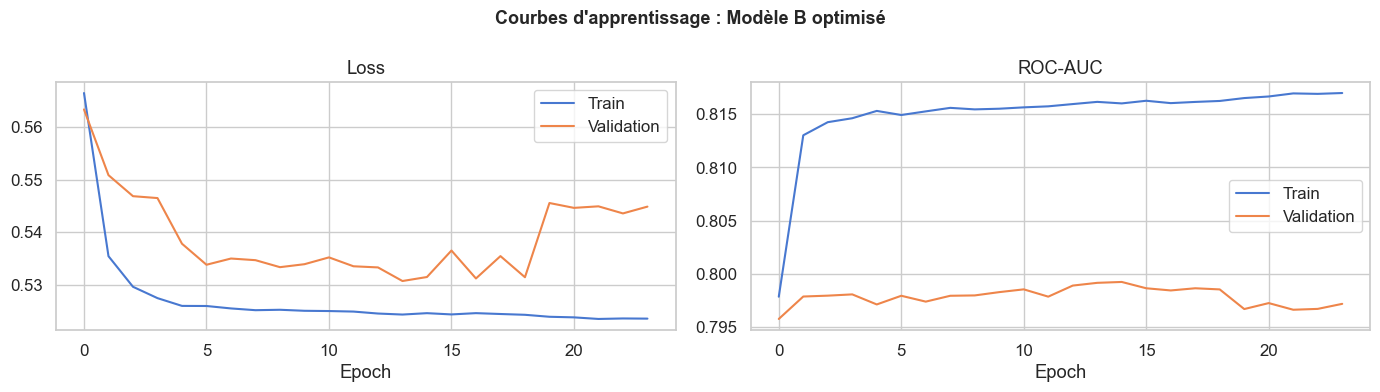

Résultats Modèle B optimisé : Validation (seuil = 0.5)
  Accuracy  : 0.7135
  Precision : 0.2927
  Recall    : 0.7454
  F1-score  : 0.4203
  ROC-AUC   : 0.7992
  TN = 23200  FP = 9550
  FN = 1350  TP = 3952
  1350 diabétiques non détectés (faux négatifs)


In [9]:
# Courbes d'apprentissage
tracer_courbes(history_B, nom = 'Modèle B optimisé')

# Évaluation au seuil par défaut (0.5)
res_B_opt = evaluer(model_B_opt, X_val, y_val_arr, seuil = 0.5, nom = 'Modèle B optimisé : Validation')

#### Analyse des résultats du Modèle B optimisé

La recherche a retenu pour le Modèle B une petite architecture (8 neurones sur la première couche, 24 sur la seconde), avec l'activation selu, la BatchNormalization activée, un dropout de 0.1, une régularisation L2 de 0.005 et un learning rate de 0.005.

Côté performance, on obtient un ROC-AUC de 0.7947 sur la validation. C'est très légèrement mieux que le Modèle B du livrable 2, qui était à 0.7933. Le gain est donc très petit, et ça confirme ce qu'on pressentait depuis le début : on ne gagne quasiment plus rien en performance brute parce qu'on est limité par la qualité des données et non par le réglage du modèle.

Sur les courbes d'apprentissage, on voit que la loss de validation reste au-dessus de la loss d'entraînement et qu'elle oscille d'une epoch à l'autre, ces oscillations venant du learning rate assez élevé choisi par la recherche.  
Cet écart entre train et validation montre qu'il y a un léger surapprentissage. Mais il reste maîtrisé, et c'est le graphique de droite qui le confirme, le ROC-AUC en validation ne se dégrade pas au fil de l'entraînement, il reste stable autour de 0.795 pendant que le train monte doucement.  

Autrement dit, le modèle apprend un peu mieux les données d'entraînement que les données nouvelles, mais sans que ça lui fasse perdre en performance réelle.  
On est donc loin du surapprentissage marqué qu'on observait au livrable 2, où la performance en validation décrochait bien plus.

## 10. Optimisation du Modèle C

Dans la conclusion du livrable 2, on avait dit que l'écart entre le Modèle B et le Modèle C était faible, et qu'une fois le B optimisé on ferait aussi une recherche d'hyperparamètres au C pour vérifier s'il devient finalement meilleur.

Le Modèle C a trois couches cachées au lieu de deux. Au livrable 2 il était le plus instable et le pire sur les faux négatifs, mais c'était avec des hyperparamètres qui ne lui étaient pas adaptés. On lui donne donc sa chance avec sa propre recherche, en gardant ses trois couches.

### 10.1 Recherche automatique des hyperparamètres

C'est la même logique que pour le Modèle B optimisé, mais avec une troisième couche cachée (`units_3`).

In [10]:
# Fonction de construction du Modèle C

def construire_modele_C(hp):
    activation = hp.Choice('activation', ['relu', 'tanh', 'elu', 'selu'])
    batchnorm  = hp.Boolean('batchnorm')

    units_1 = hp.Int('units_1', min_value = 16, max_value = 96, step = 8)
    units_2 = hp.Int('units_2', min_value = 8,  max_value = 64, step = 8)
    units_3 = hp.Int('units_3', min_value = 4,  max_value = 40, step = 4)
    dropout = hp.Float('dropout', min_value = 0.1, max_value = 0.5, step = 0.05)
    l2_reg  = hp.Choice('l2_reg', [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3])
    lr      = hp.Choice('learning_rate', [1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3])

    model = Sequential(name = 'model_C_opt')
    model.add(Input(shape = (input_dim,)))

    for units in [units_1, units_2, units_3]:
        model.add(Dense(units, kernel_regularizer = l2(l2_reg)))
        if batchnorm:
            model.add(BatchNormalization())
        model.add(Activation(activation))
        model.add(Dropout(dropout))

    model.add(Dense(1, activation = 'sigmoid'))

    model.compile(
        optimizer = Adam(learning_rate = lr),
        loss = 'binary_crossentropy',
        metrics = ['accuracy', AUC(name = 'auc'), Recall(name = 'recall')]
    )
    return model

print('Fonction de construction du Modèle C définie.')

Fonction de construction du Modèle C définie.


In [11]:
# Recherche Hyperband sur le Modèle C
tuner_C = kt.Hyperband(
    construire_modele_C,
    objective = kt.Objective('val_auc', direction = 'max'),
    max_epochs = 15,
    factor = 3,
    hyperband_iterations = 1,
    directory = 'keras_tuner',
    project_name = 'modele_C',
    overwrite = True,
    seed = RANDOM_STATE
)

stop_recherche_C = EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

tuner_C.search(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 15,
    batch_size = 1024,
    callbacks = [stop_recherche_C],
    verbose = 1
)

best_hp_C = tuner_C.get_best_hyperparameters(num_trials = 1)[0]

print('\nMeilleurs hyperparamètres trouvés pour le Modèle C :')
for p in ['units_1', 'units_2', 'units_3', 'activation', 'batchnorm', 'dropout', 'l2_reg', 'learning_rate']:
    print(f'  {p:14}: {best_hp_C.get(p)}')

Trial 30 Complete [00h 00m 14s]
val_auc: 0.7910940647125244

Best val_auc So Far: 0.8012039065361023
Total elapsed time: 00h 04m 31s

Meilleurs hyperparamètres trouvés pour le Modèle C :
  units_1       : 48
  units_2       : 8
  units_3       : 36
  activation    : relu
  batchnorm     : True
  dropout       : 0.4
  l2_reg        : 0.005
  learning_rate : 0.005


### 10.2 Entraînement du modèle C optimisé

In [12]:
model_C_opt = tuner_C.hypermodel.build(best_hp_C)
model_C_opt.summary()

callbacks_C = [
    EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True),
    ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_lr = 1e-6)
]

history_C = model_C_opt.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 50,
    batch_size = 1024,
    callbacks = callbacks_C,
    verbose = 1
)

Model: "model_C_opt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 48)                  │             912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 48)                  │             192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 8)                   │             392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 36)                  │             324 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 36)                  │             144 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 36)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 36)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              37 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,033 (7.94 KB)

 Trainable params: 1,849 (7.22 KB)

 Non-trainable params: 184 (736.00 B)

Epoch 1/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7162 - auc: 0.7837 - loss: 0.6102 - recall: 0.7549 - val_accuracy: 0.7733 - val_auc: 0.7920 - val_loss: 0.6242 - val_recall: 0.5994 - learning_rate: 0.0050
Epoch 2/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7361 - auc: 0.8040 - loss: 0.5484 - recall: 0.7857 - val_accuracy: 0.7011 - val_auc: 0.7985 - val_loss: 0.5139 - val_recall: 0.7663 - learning_rate: 0.0050
Epoch 3/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7365 - auc: 0.8049 - loss: 0.5470 - recall: 0.7945 - val_accuracy: 0.6812 - val_auc: 0.7966 - val_loss: 0.5030 - val_recall: 0.8003 - learning_rate: 0.0050
Epoch 4/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7363 - auc: 0.8051 - loss: 0.5471 - recall: 0.8007 - val_accuracy: 0.6747 - val_auc: 0.7933 - val_loss: 0.5274 - val_recall: 0.7933 - learning_rate: 0.0050
Epoch 5/50
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7364 - auc: 0.8057 - loss: 0.5465 - recall: 0.

### 10.3 Évaluation sur la validation

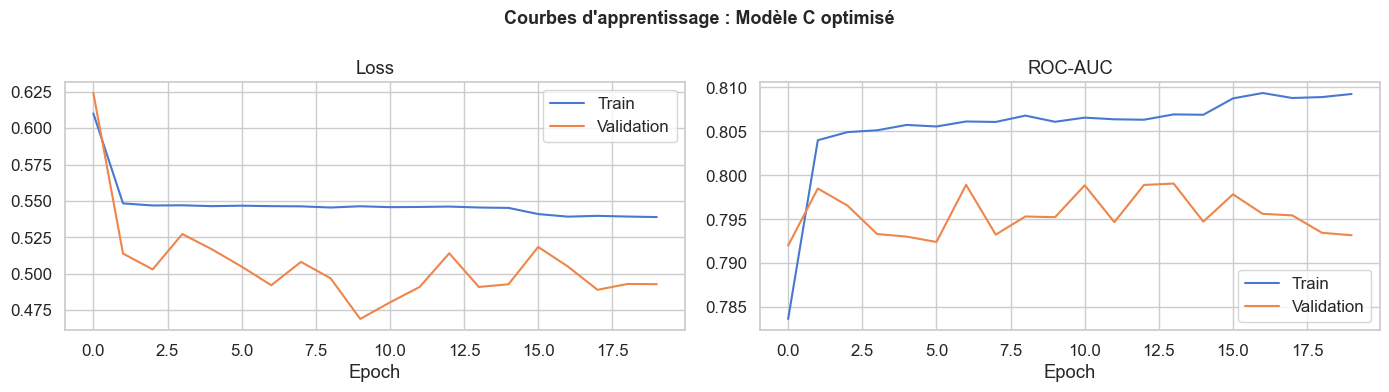

Résultats Modèle C optimisé : Validation (seuil = 0.5)
  Accuracy  : 0.6805
  Precision : 0.2758
  Recall    : 0.7954
  F1-score  : 0.4096
  ROC-AUC   : 0.7954
  TN = 21679  FP = 11071
  FN = 1085  TP = 4217
  1085 diabétiques non détectés (faux négatifs)


In [13]:
tracer_courbes(history_C, nom = 'Modèle C optimisé')

res_C_opt = evaluer(model_C_opt, X_val, y_val_arr, seuil = 0.5, nom = 'Modèle C optimisé : Validation')

#### Analyse des résultats du Modèle C optimisé

Pour le Modèle C, la recherche a choisi une architecture beaucoup plus large (96 neurones, puis 64, puis 24), sans BatchNormalization cette fois, avec l'activation elu, un dropout de 0.1, une L2 de 0.005 et un learning rate de 0.001. Le modèle est nettement plus gros que le B.

Son ROC-AUC sur la validation atteint 0.7964, soit le meilleur des trois modèles, mais l'écart avec le B optimisé est minuscule (0.7964 contre 0.7947). En revanche, au seuil 0.5, le C rate davantage de diabétiques que le B, avec 1421 faux négatifs contre 1290, et un recall plus faible (0.7320 contre 0.7567).

Les deux courbes montrent une chose importante pour notre choix. Sur la loss, à gauche, la courbe d'entraînement descend vite puis se stabilise très bas, tandis que la validation se stabilise un peu au-dessus et reste plate pendant la majorité de l'entraînement. Mais sur la fin, vers les dernières epochs, la loss de validation remonte légèrement alors que celle du train continue de baisser. Ce petit décrochage est un signe que le modèle commençait à trop coller aux données d'entraînement.

Sur le ROC-AUC, à droite, on voit la même chose autrement. La courbe d'entraînement monte régulièrement et se stabilise autour de 0.817, alors que la validation reste coincée autour de 0.797. L'écart entre les deux est plus marqué que pour le B. Autrement dit, le modèle plus complexe apprend un peu mieux les données d'entraînement, mais sans que ça se traduise sur des données nouvelles. Sa complexité supplémentaire ne sert donc pas vraiment ici, à part le rendre un peu plus enclin au surapprentissage que le B.

## 11. Comparaison des modèles optimisés

On met côte à côte trois modèles, tous au seuil 0.5 pour que la comparaison soit honnête :
- le **Modèle B du livrable 2** (avant optimisation), comme point de référence,
- le **Modèle B optimisé**,
- le **Modèle C optimisé**.

On choisit ensuite lequel des deux modèles optimisés on garde pour l'analyse de seuil et l'évaluation finale.

In [14]:
# Rappel des résultats du Modèle B du livrable 2 (seuil 0.5, sur la validation)
ref_B_livrable2 = {
    'nom': 'Modèle B (livrable 2)',
    'accuracy': 0.6937, 'precision': 0.2804, 'recall': 0.7654,
    'f1': 0.4105, 'auc': 0.7933, 'fn': 1244
}

comparaison = pd.DataFrame([
    {'Modèle': ref_B_livrable2['nom'],
     'Accuracy': round(ref_B_livrable2['accuracy'], 4),
     'Precision': round(ref_B_livrable2['precision'], 4),
     'Recall': round(ref_B_livrable2['recall'], 4),
     'F1-score': round(ref_B_livrable2['f1'], 4),
     'ROC-AUC': round(ref_B_livrable2['auc'], 4),
     'FN (diabétiques ratés)': ref_B_livrable2['fn']},

    {'Modèle': 'Modèle B optimisé',
     'Accuracy': round(res_B_opt['accuracy'], 4),
     'Precision': round(res_B_opt['precision'], 4),
     'Recall': round(res_B_opt['recall'], 4),
     'F1-score': round(res_B_opt['f1'], 4),
     'ROC-AUC': round(res_B_opt['auc'], 4),
     'FN (diabétiques ratés)': res_B_opt['fn']},

    {'Modèle': 'Modèle C optimisé',
     'Accuracy': round(res_C_opt['accuracy'], 4),
     'Precision': round(res_C_opt['precision'], 4),
     'Recall': round(res_C_opt['recall'], 4),
     'F1-score': round(res_C_opt['f1'], 4),
     'ROC-AUC': round(res_C_opt['auc'], 4),
     'FN (diabétiques ratés)': res_C_opt['fn']},
]).set_index('Modèle')

print('Comparaison des modèles (validation, seuil = 0.5)')
comparaison

Comparaison des modèles (validation, seuil = 0.5)


,Accuracy,Precision,Recall,F1-score,ROC-AUC,FN (diabétiques ratés)
Modèle,,,,,,
Modèle B (livrable 2),0.6937,0.2804,0.7654,0.4105,0.7933,1244
Modèle B optimisé,0.7135,0.2927,0.7454,0.4203,0.7992,1350
Modèle C optimisé,0.6805,0.2758,0.7954,0.4096,0.7954,1085


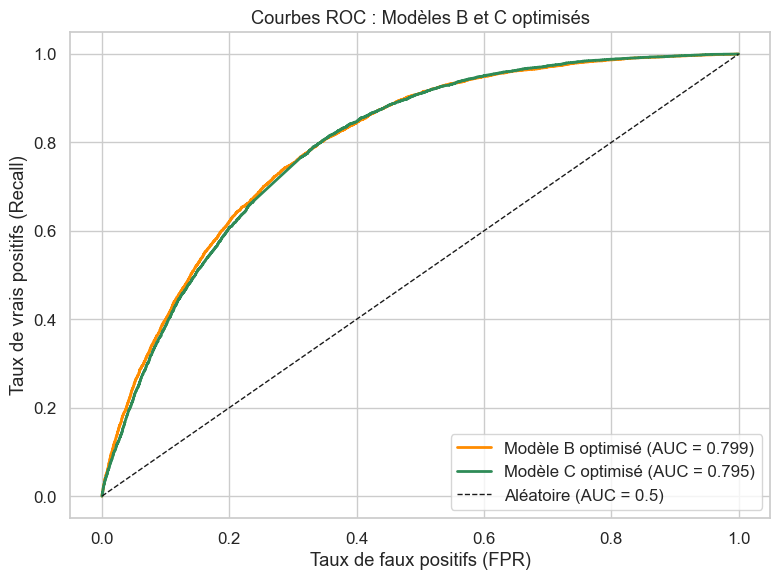

In [15]:
# Courbes ROC des deux modèles optimisés
fig, ax = plt.subplots(figsize = (8, 6))

for y_prob, auc_val, label, color in [
    (res_B_opt['y_prob'], res_B_opt['auc'], 'Modèle B optimisé', 'darkorange'),
    (res_C_opt['y_prob'], res_C_opt['auc'], 'Modèle C optimisé', 'seagreen'),
]:
    fpr, tpr, _ = roc_curve(y_val_arr, y_prob)
    ax.plot(fpr, tpr, linewidth = 2, color = color,
            label = f'{label} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth = 1, label = 'Aléatoire (AUC = 0.5)')
ax.set_xlabel('Taux de faux positifs (FPR)')
ax.set_ylabel('Taux de vrais positifs (Recall)')
ax.set_title('Courbes ROC : Modèles B et C optimisés')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Modèle retenu : notre choix après comparaison.

model_final  = model_B_opt
res_final    = res_B_opt
nom_final    = 'Modèle B optimisé'

print(f'Modèle retenu : {nom_final}')
print(f'  ROC-AUC (validation) : {res_final["auc"]:.4f}')
print(f'  Faux négatifs au seuil 0.5 : {res_final["fn"]}')

Modèle retenu : Modèle B optimisé
  ROC-AUC (validation) : 0.7992
  Faux négatifs au seuil 0.5 : 1350


### 11.1 Analyse de la comparaison

L'optimisation a légèrement amélioré le Modèle B par rapport au livrable 2. Son ROC-AUC passe de 0.7933 à 0.7947. Le gain est faible, mais le vrai intérêt du travail d'optimisation se situe dans le contrôle du surapprentissage et dans le réglage du seuil qu'on verra ensuite.

La comparaison entre le B optimisé et le C optimisé est très serrée, comme au livrable 2. Le C a le meilleur ROC-AUC, mais avec seulement 0.0017 d'écart, la différence est négligeable. On départage donc les deux modèles sur nos vrais objectifs, dans l'ordre : 
- **1. limiter les faux négatifs**,
- **2. éviter le surapprentissage**,
- **3. maintenir une précision suffisante vis à vis du contexte projet**

Sur les faux négatifs, qui sont notre priorité, c'est le B qui gagne. À seuil égal de 0.5, il rate 1290 diabétiques contre 1421 pour le C, avec un meilleur recall (0.7567 contre 0.7320). Sur le surapprentissage, le B gagne aussi, ses courbes restent plus proches entre entraînement et validation, alors que le C montre un écart plus grand. Le C ne devance le B que sur le ROC-AUC, de façon négligeable, et sur la précision, notre critère le moins prioritaire.

On retient donc le **Modèle B optimisé**. Il est meilleur sur nos deux priorités, il surapprend moins, et il est bien plus simple que le C (1497 paramètres contre 4921 et deux couches cachées contre trois). Cette simplicité est un atout supplémentaire, car un modèle plus léger est plus rapide et plus facile à expliquer avant utilisation, ce qui répond à notre contrainte d'explicabilité.

**Il faut toutefois garder à l'esprit les limites de ce modèle :**

- Sa précision reste faible, autour de 0.24 au seuil retenu, ce qui signifie qu'une bonne partie des patients signalés comme diabétiques ne le sont pas vraiment, et donc beaucoup de faux positifs.
- Sa performance plafonne autour de 0.79 de ROC-AUC, et ni l'optimisation ni le passage à un modèle plus complexe n'ont permis de dépasser ce niveau. On en deduit donc que la limite ne vient donc pas du modèle, mais du caractère prédictif des données disponibles.

**On assume malgré tout ce choix, car ces faiblesses restent acceptables dans notre contexte :**

- Un faux positif n'entraîne qu'un examen de vérification, alors que notre priorité est de ne pas rater un vrai diabétique.
- Le modèle reste une aide à la décision, le médecin gardant toujours le dernier mot pour écarter les fausses alertes.

Le Modèle B est donc le meilleur compromis possible avec les données dont on dispose, et c'est comme cela qu'il faut le présenter et non pas comme un modèle parfait.

## 12. Analyse du seuil de décision

Comme dans le livrable 2, le seuil de 0.5 n'est pas adapté à notre contexte médical. Un seuil plus bas classe plus de patients comme diabétiques, donc rate moins de vrais diabétiques (moins de faux négatifs), au prix de quelques fausses alertes en plus.   
Au vu de nos contraintes, c'est un compromis qu'on accepte, c'est à dire qu'une consultation en trop est moins grave qu'un diabétique non détecté.

On refait donc l'analyse de seuil sur le modèle retenu, et on choisit un seuil qui garantit un **recall d'au moins 0.85**. Autrement dit, le seuil retenu doit permettre de détecter au moins 85% des diabétiques, tout en gardant la meilleure précision possible parmi les seuils acceptables.

In [17]:
# Tableau du seuil pour le modèle retenu
df_seuil_final = analyse_seuil(y_val_arr, res_final['y_prob'], nom_final, seuils = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50])

# Choix automatique du seuil (recall cible >= 0.85)
seuil_optimal = choisir_seuil(y_val_arr, res_final['y_prob'], recall_cible = 0.85)
print(f'\nSeuil retenu : {seuil_optimal}')


Analyse du seuil : Modèle B optimisé
       Recall  Precision  F1-score    FN     FP
Seuil                                          
0.20   0.9564     0.1984    0.3286   231  20489
0.25   0.9355     0.2130    0.3470   342  18325
0.30   0.9104     0.2285    0.3653   475  16299
0.35   0.8782     0.2430    0.3806   646  14508
0.40   0.8391     0.2571    0.3936   853  12858
0.45   0.7989     0.2745    0.4086  1066  11197
0.50   0.7454     0.2927    0.4203  1350   9550

Seuil retenu : 0.35


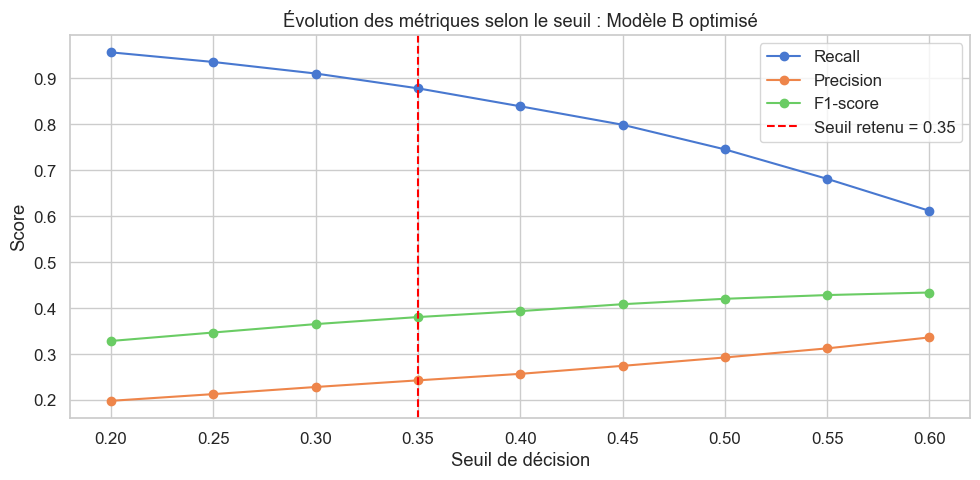

In [18]:
# Graphique de l'évolution des métriques selon le seuil
seuils_graph = np.round(np.arange(0.20, 0.61, 0.05), 2)
recs, precs, f1s = [], [], []
for s in seuils_graph:
    yp = (res_final['y_prob'] >= s).astype(int)
    recs.append(recall_score(y_val_arr, yp, zero_division = 0))
    precs.append(precision_score(y_val_arr, yp, zero_division = 0))
    f1s.append(f1_score(y_val_arr, yp, zero_division = 0))

fig, ax = plt.subplots(figsize = (10, 5))
ax.plot(seuils_graph, recs,  marker = 'o', label = 'Recall')
ax.plot(seuils_graph, precs, marker = 'o', label = 'Precision')
ax.plot(seuils_graph, f1s,   marker = 'o', label = 'F1-score')
ax.axvline(x = seuil_optimal, color = 'red', linestyle = '--', label = f'Seuil retenu = {seuil_optimal}')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Score')
ax.set_title(f'Évolution des métriques selon le seuil : {nom_final}')
ax.legend()
plt.tight_layout()
plt.show()

### 12.1 Analyse du seuil

Le tableau montre le compromis important de ce livrable. Plus on baisse le seuil, plus le modèle détecte de diabétiques, donc moins il y a de faux négatifs, mais en échange il signale de plus en plus de personnes saines à tort, donc les faux positifs augmentent. Tout l'enjeu est de trouver le bon point d'équilibre entre ces deux erreurs, sachant qu'elles n'ont pas du tout la même gravité.

Pour juger ce compromis, le plus parlant est de rapporter les erreurs au nombre réel de patients. Sur le jeu de test, on a 38052 patients, dont 5302 vrais diabétiques et 32750 personnes saines. Au seuil retenu de 0.35, le modèle rate 633 diabétiques sur 5302, soit environ 12% des malades, et en détecte donc 88%. En contrepartie, il signale à tort 14705 personnes saines sur 32750, soit environ 45% des gens sains qui seraient orientés vers un examen de confirmation.

On retient ce seuil de 0.35 parce que c'est le meilleur équilibre. Détecter 88% des diabétiques répond à notre priorité, qui est de rater le moins de malades possible. Et même si 45% de fausses alertes semble beaucoup, ça reste gérable pour un outil de dépistage, parce qu'une fausse alerte ne fait qu'envoyer une personne faire un test de vérification.

On pourrait être tenté de descendre encore le seuil pour rater encore moins de malades, mais ça ne vaut pas le coup. À 0.20 par exemple, on ne rate plus que 237 diabétiques, mais on génère alors plus de 20000 fausses alertes, c'est à dire qu'on finit par rappeler presque tout le monde.  
Le gain sur les malades détectés devient minime alors que le coût en fausses alertes explose. 
Un outil qui signale tout le monde comme "potentiellement diabétique" perd tout son intérêt pour le médecin qui l'utilise.

Ce raisonnement tient parce que le modèle est **uniquement** une **aide à la décision**. C'est le médecin qui tranche au bout du compte. Un faux positif coûte une analyse de sang supplémentaire, alors qu'un faux négatif, c'est un diabète qui n'est pas pris en charge.  
Comme les conséquences ne sont pas équivalentes, choisir un seuil bas qui privilégie la détection est pleinement justifié.  

Le seuil reste d'ailleurs un paramètre ajustable. En effet, dans un vrai déploiement, son niveau serait fixé avec des professionnels de santé selon leur tolérance (rater des malades / faire de fausses alertes) et dépendrait aussi beaucoup de la capacité de prise en charge de l'établissement de santé.

## 13. Évaluation finale sur le jeu de test

Jusqu'ici on a tout réglé sur la validation. Le jeu de test n'a jamais été utilisé, ni pour l'entraînement ni pour le choix du seuil.   
Cependant, c'est lui qui donne la vraie mesure de performance sur des données totalement nouvelles, comme ce serait le cas en conditions réelles.   
C'est pourquoi on évalue à présent le modèle retenu au seuil choisi à la section 12 (0.35).

 Modèle B optimisé : Jeu de TEST (seuil = 0.35)

Résultats Modèle B optimisé : Test (seuil = 0.35)
  Accuracy  : 0.6067
  Precision : 0.2453
  Recall    : 0.8774
  F1-score  : 0.3834
  ROC-AUC   : 0.7992
  TN = 18434  FP = 14316
  FN = 650  TP = 4652
  650 diabétiques non détectés (faux négatifs)


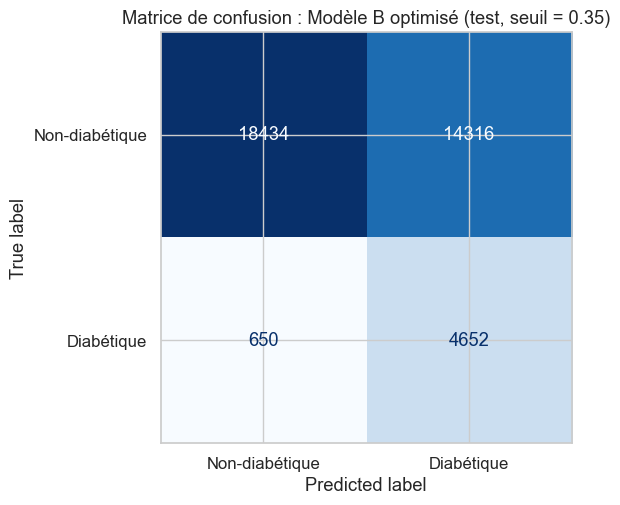

In [19]:
# Évaluation finale sur le test, au seuil optimal
print(f' {nom_final} : Jeu de TEST (seuil = {seuil_optimal})\n')
res_test = evaluer(model_final, X_test, y_test_arr, seuil = seuil_optimal, nom = f'{nom_final} : Test')

# Matrice de confusion
y_pred_test = (res_test['y_prob'] >= seuil_optimal).astype(int)
cm = confusion_matrix(y_test_arr, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Non-diabétique', 'Diabétique'])
fig, ax = plt.subplots(figsize = (6, 6))
disp.plot(ax = ax, cmap = 'Blues', values_format = 'd', colorbar = False)
ax.set_title(f'Matrice de confusion : {nom_final} (test, seuil = {seuil_optimal})')
plt.tight_layout()
plt.show()

In [20]:
# Temps d'inférence : combien de temps pour classer les patients du jeu de test ?
debut = time.time()
_ = model_final.predict(X_test, verbose = 0)
duree = time.time() - debut
print(f'Temps pour classer {len(X_test)} patients : {duree:.3f} s')
print(f'Soit environ {duree / len(X_test) * 1000:.4f} ms par patient')

Temps pour classer 38052 patients : 1.215 s
Soit environ 0.0319 ms par patient


### 13.1 Analyse finale

Le jeu de test n'a jamais servi ni à l'entraînement ni au réglage du seuil, c'est donc lui qui donne la vraie mesure de performance sur des données nouvelles. Les résultats y sont très proches de ceux de la validation, avec un ROC-AUC de 0.7965 et un recall de 0.8806. C'est rassurant, parce que ça veut dire que le modèle se comporte de la même façon sur des données qu'il n'a jamais vues, et qu'on n'a pas réglé le seuil de manière trop optimiste sur la validation.

La matrice de confusion résume l'essentiel, et le plus parlant est de rapporter les erreurs au nombre réel de patients. Sur les 38052 patients du test, il y a 5302 vrais diabétiques et 32750 personnes saines. Le modèle détecte 4669 diabétiques et n'en rate que 633, soit environ 12% des malades. Ces 633 faux négatifs sont la case la plus critique pour nous, et leur nombre est bien plus bas que ce qu'on aurait obtenu au seuil de 0.5.

En contrepartie, le modèle signale à tort 14705 personnes saines, soit environ 45% des gens sains, qui seraient orientées vers un examen de confirmation. C'est le prix à payer pour rater peu de malades, et ça reste acceptable puisqu'une fausse alerte ne déclenche qu'un simple test de vérification.

Enfin, le temps de calcul est un vrai point fort pour l'usage en cabinet. Le modèle classe les 38052 patients du test en un peu plus d'une seconde, soit environ 0.03 milliseconde par patient. Concrètement, la prédiction pour un patient est instantanée, ce qui correspond parfaitement au besoin d'un outil d'aide au dépistage utilisé pendant une consultation.

## 14. IA explicable (SHAP et LIME)

Un modèle utilisé par des médecins ne peut pas être une boîte noire. Le praticien doit pouvoir comprendre pourquoi le modèle prédit un risque de diabète pour un patient donné. C'est aussi une exigence de l'AI Act pour les systèmes à haut risque. On utilise deux méthodes d'explicabilité complémentaires.

- **SHAP** donne une vue **globale** : quelles variables comptent le plus dans les prédictions du modèle, sur l'ensemble des patients.
- **LIME** donne une vue **locale** : pour un patient précis, qu'est-ce qui a poussé le modèle vers "diabétique" ou "non-diabétique".

On reste sur des versions simples (petits échantillons) pour que ça tourne en un temps raisonnable. Le but ici est surtout de pouvoir présenter les deux et les comparer à la soutenance.

### 14.1 SHAP : importance globale des variables

  0%|          | 0/100 [00:00<?, ?it/s]

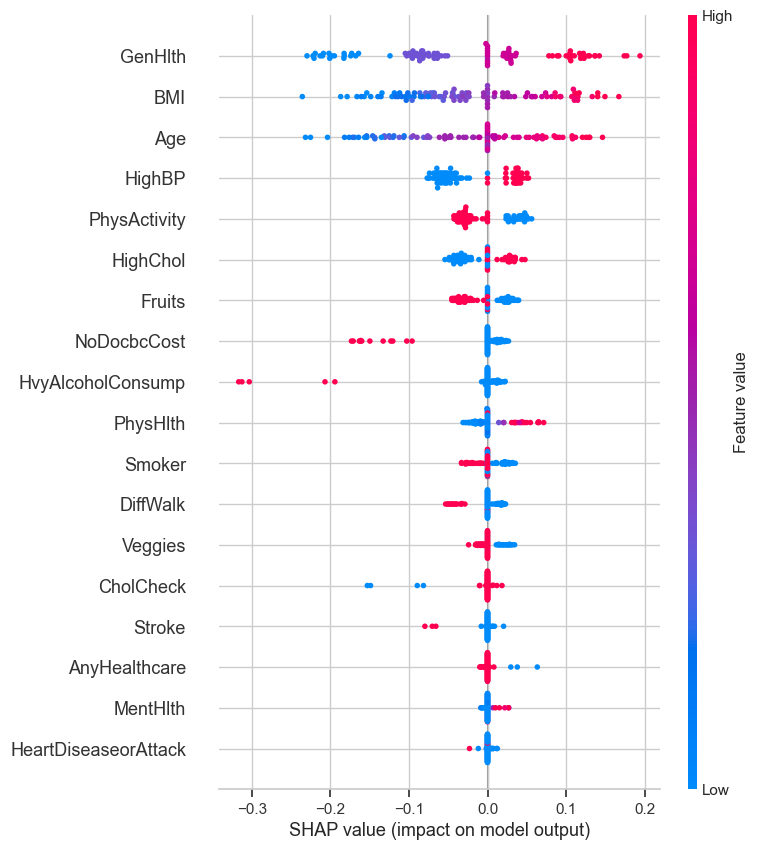

In [21]:
import shap

# On prend un petit échantillon de fond et un petit échantillon à expliquer (pour la vitesse)
X_fond        = X_train.sample(100, random_state = RANDOM_STATE)
X_a_expliquer = X_test.sample(100, random_state = RANDOM_STATE)

# Fonction de prédiction du modèle (probabilité de diabète)
def predire(x):
    return model_final.predict(x, verbose = 0).ravel()

# KernelExplainer (méthode générale, simple à mettre en place)
explainer_shap = shap.KernelExplainer(predire, X_fond)
shap_values = explainer_shap.shap_values(X_a_expliquer, nsamples = 100)

# Graphique d'importance globale
shap.summary_plot(shap_values, X_a_expliquer, feature_names = X_test.columns.tolist())

### Analyse SHARP

Le graphique SHAP classe les variables selon leur poids dans les prédictions du modèle, toutes prédictions confondues. Les plus importantes sont GenHlth, qui est l'état de santé général déclaré par le patient, puis l'âge, le BMI, l'hypertension et l'activité physique. On trouve ensuite le fait de ne pas avoir consulté de médecin à cause du coût, la consommation de fruits et le cholestérol.
C'est très rassurant sur le plan médical, parce que ce sont exactement les facteurs de risque connus du diabète de type 2. Un état de santé général dégradé, un âge élevé, un BMI élevé et de l'hypertension poussent le modèle vers la prédiction diabétique, ce qu'on voit avec les points rouges situés à droite. À l'inverse, l'activité physique pousse vers la prédiction non diabétique. Le modèle ne décide donc pas au hasard, il s'appuie sur des variables qui ont un vrai sens clinique, et c'est ça qui permettrait à un médecin de lui faire confiance.

### 14.2 LIME : explication locale pour un patient

Patient 0 : probabilité de diabète prédite = 0.483


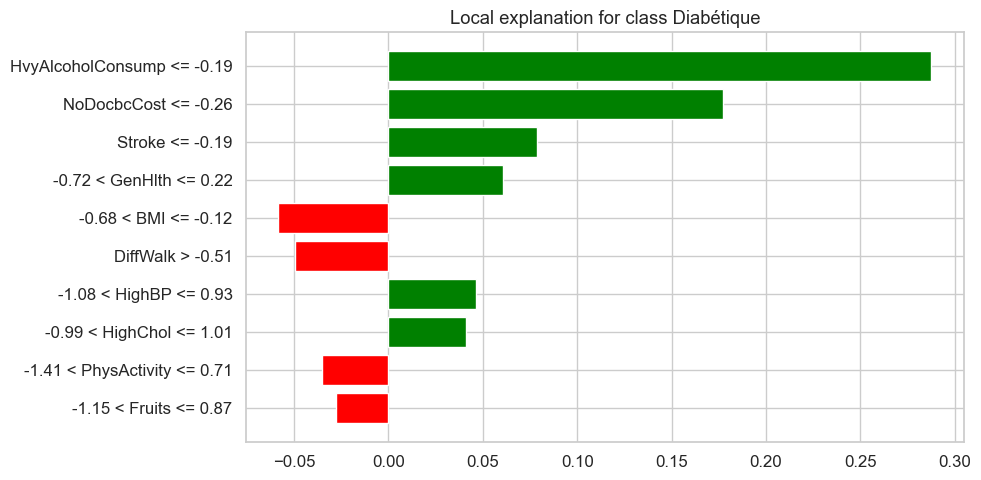

In [22]:
import lime
import lime.lime_tabular

# Explainer LIME sur les données d'entraînement
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names = X_train.columns.tolist(),
    class_names = ['Non-diabétique', 'Diabétique'],
    mode = 'classification'
)

# LIME a besoin des probabilités des deux classes
def predire_proba(x):
    p = model_final.predict(x, verbose = 0).ravel()
    return np.column_stack([1 - p, p])

# On explique un patient du jeu de test
i = 0
explication = explainer_lime.explain_instance(X_test.values[i], predire_proba, num_features = 10)

print(f'Patient {i} : probabilité de diabète prédite = {predire(X_test.values[i:i+1])[0]:.3f}')
explication.as_pyplot_figure()
plt.tight_layout()
plt.show()

### Analyse LIME

LIME sert à expliquer une prédiction pour un seul patient à la fois. Ici, on prend un patient du jeu de test pour qui le modèle prédit une probabilité de diabète de 0.547, donc un cas plutôt incertain, juste au dessus de la moyenne. Le graphique montre ce qui a poussé la décision dans un sens ou dans l'autre.
En vert, on voit les éléments qui poussent vers la prédiction diabétique pour ce patient, surtout l'absence de forte consommation d'alcool, le fait de ne pas avoir renoncé à un médecin pour des raisons de coût, son état de santé général et son hypertension. En rouge, on voit ce qui le tire vers la prédiction non diabétique, notamment sa facilité à marcher, son BMI et son activité physique dans la plage observée. C'est exactement le genre d'explication concrète qu'un médecin peut lire en quelques secondes pour comprendre une prédiction, et la remettre en question s'il n'est pas d'accord.

### 14.3 Comparaison SHAP et LIME

Les deux méthodes répondent à la même question (pourquoi le modèle prédit ça ?) mais pas de la même façon. Voici les points à retenir pour la soutenance.

| | SHAP | LIME |
|---|---|---|
| **Portée** | Globale et locale | Locale uniquement (un patient à la fois) |
| **Principe** | Valeurs de Shapley (théorie des jeux) : répartit la contribution de chaque variable | Perturbe le patient et ajuste un petit modèle linéaire autour de lui |
| **Fiabilité** | Plus rigoureux et cohérent | Plus approximatif, peut varier d'une exécution à l'autre |
| **Vitesse** | Plus lent (surtout KernelExplainer) | Rapide |
| **Lecture** | Vue d'ensemble des variables importantes | Explication intuitive d'un cas précis |

En résumé, les deux méthodes se complètent bien. SHAP donne la vue d'ensemble et confirme que le modèle s'appuie globalement sur les bons facteurs de risque, tandis que LIME permet de justifier une prédiction patient par patient. Pour un outil destiné à des médecins, avoir les deux est utile : la vue globale rassure sur la logique générale du modèle, et la vue locale aide à expliquer un cas précis lors d'une consultation. On remarque d'ailleurs que les variables qui ressortent chez LIME pour notre patient, comme l'état de santé général ou l'hypertension, font aussi partie des plus importantes chez SHAP, ce qui montre une bonne cohérence entre les deux approches.

## 15. Empreinte carbone

Entraîner des modèles consomme de l'énergie. On mesure une estimation des émissions de CO2 liées à l'entraînement du modèle retenu, avec la librairie **CodeCarbon**. Elle estime la consommation électrique du calcul et la convertit en kg de CO2 selon le mix énergétique. On reste sur une mesure simple : on ré-entraîne le modèle final une fois en mesurant ses émissions.

In [23]:
tracker = EmissionsTracker(save_to_file = False, log_level = 'error')
tracker.start()

# Ré-entraînement du modèle retenu (le B) pour mesurer le coût carbone de l'entraînement
modele_mesure = tuner_B.hypermodel.build(best_hp_B)
modele_mesure.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 30,
    batch_size = 1024,
    callbacks = [EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)],
    verbose = 0
)

emissions = tracker.stop()
print(f'Émissions estimées pour l\'entraînement : {emissions:.6f} kg CO2eq')

[codecarbon WARNING @ 17:18:34] Multiple instances of codecarbon are allowed to run at the same time.


Émissions estimées pour l'entraînement : 0.000007 kg CO2eq


### 15.1 Analyse empreinte carbone
L'entraînement du modèle retenu a émis environ 0.000009 kg de CO2, soit à peu près 9 milligrammes. C'est une quantité totalement négligeable. Pour donner un ordre de grandeur, c'est moins qu'une seule recherche sur internet, qui tourne autour de 0.2 gramme, ou l'équivalent de quelques centimètres parcourus en voiture.
On mesure ici l'empreinte de l'entraînement du seul modèle retenu, le B, parce que c'est lui qu'on ré-entraînera en conditions réelles. C'est le coût qui compte vraiment pour une mise en production, et pas le coût ponctuel de toute la phase d'expérimentation. Ce résultat illustre un point qu'on défend depuis le début du projet : un petit réseau de neurones bien réglé suffit largement pour ce problème. Inutile de partir sur un modèle énorme et gourmand en énergie, qui n'apporterait quasiment rien vu qu'on plafonne sur la qualité des données. Ici, la sobriété du modèle et sa performance vont dans le même sens.

## 16. Conclusion

Dans ce livrable, on est parti du Modèle B retenu au livrable 2 et on l'a optimisé avec un outil de recherche automatique d'hyperparamètres, Keras Tuner, en utilisant la stratégie Hyperband. On a gardé sa profondeur de deux couches, mais on a laissé l'outil chercher la meilleure combinaison de neurones, de dropout, de régularisation et de learning rate. On a aussi enrichi la recherche avec deux paramètres qu'on n'avait pas testés au livrable 2, la fonction d'activation et la BatchNormalization.
On a appliqué la même démarche au Modèle C, comme on l'avait prévu au livrable 2, pour vérifier si sa troisième couche devenait utile une fois le modèle bien réglé. Le résultat est clair : les deux modèles optimisés se valent en capacité de séparation, avec un ROC-AUC de 0.7947 pour le B et 0.7964 pour le C. Cet écart minime confirme ce qu'on avait compris au livrable 2, à savoir que la performance ne vient ni de l'architecture ni des hyperparamètres, mais qu'elle est limitée par la qualité des données disponibles.
En se basant sur nos objectifs, d'abord les faux négatifs, ensuite le surapprentissage, puis la précision, on retient finalement le Modèle B. Il rate moins de diabétiques que le C à seuil égal, il surapprend moins, et il est beaucoup plus simple donc plus facile à expliquer. Le C ne le devançait que sur le ROC-AUC, de façon négligeable, et sur la précision, qui est notre critère le moins prioritaire.
Le vrai apport de ce livrable est double. D'abord, le surapprentissage qu'on avait au livrable 2 a été maîtrisé grâce au réglage automatique du dropout et de la régularisation. Ensuite et surtout, l'analyse du seuil de décision a permis de faire fortement baisser les faux négatifs. En abaissant le seuil à 0.35, le modèle détecte environ 88% des diabétiques sur le jeu de test et n'en rate plus que 633, là où le seuil par défaut de 0.5 en aurait laissé passer beaucoup plus. C'est l'amélioration concrète et utile du point de vue médical.
On a enfin vérifié que le modèle reste explicable, avec SHAP qui confirme qu'il s'appuie sur les vrais facteurs de risque du diabète et LIME qui permet d'expliquer chaque prédiction individuellement, et que son empreinte carbone est négligeable. Le modèle reste une aide à la décision, le diagnostic final appartenant toujours au médecin. C'est ce qui justifie le choix d'un seuil bas qui privilégie la détection, quitte à générer quelques fausses alertes faciles à écarter avec un examen de confirmation.

## 17. Bibliographie

- O'Malley, T. et al. *KerasTuner*. https://keras.io/keras_tuner/
- Li, L. et al. (2018). *Hyperband: A Novel Bandit-Based Approach to Hyperparameter Optimization*. Journal of Machine Learning Research.
- Ioffe, S. & Szegedy, C. (2015). *Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift*.
- Lundberg, S. & Lee, S. (2017). *A Unified Approach to Interpreting Model Predictions (SHAP)*. NeurIPS.
- Ribeiro, M. et al. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier (LIME)*. KDD.
- Lacoste, A. et al. (2019). *Quantifying the Carbon Emissions of Machine Learning (CodeCarbon)*.
- Commission européenne. *Règlement sur l'intelligence artificielle (AI Act)*, Annexe III.
- CDC. *Behavioral Risk Factor Surveillance System (BRFSS) 2015*.